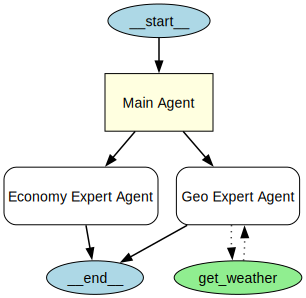

In [ ]:
from agents import Agent, Runner, function_tool, ItemHelpers, SQLiteSession, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

session = SQLiteSession("user_111111", "ai-memory.db")




@function_tool
def get_weather(city: str):
    """Get weather by city"""
    print(city)
    return "30 degrees"


geography_agent = Agent(
    name="Geo Expert Agent",
    instructions= "You are a expert in geogrphy, you answer questions about them.",
    handoff_description="Use this to answer questions about geography.",
    tools=[get_weather],

)
economics_agent = Agent(
    name = "Economy Expert Agent",
    instructions= "You are a expert in economics, you answer questions about them.",
    handoff_description="Use this to answer economics questions."
)

main_agent = Agent(
    name="Main Agent",
    instructions= "You are a user facing agent. You MUST transfer to the appropriate specialist agent for each question. Do not answer questions yourself - always handoff to the specialist agent. For geography questions, handoff to Geography Agent. For economy questions, handoff to Economy Agent.",
    handoffs=[
        economics_agent,
        geography_agent,
    ],
)

draw_graph(main_agent)

In [ ]:
with trace("user_111111"):
    result = await Runner.run(
        main_agent,
        "Tell me about columbia",
        session=session,
    )

print(result.last_agent.name)
print(result.final_output)

Economy Expert Agent
Countries sell bonds primarily to raise money to fund government activities or cover budget deficits. Here’s why:

1. **Financing Government Spending**: Governments may need more funds than they collect through taxes to pay for things like infrastructure, education, healthcare, or defense. By selling bonds, they borrow money from investors and promise to pay it back later with interest.

2. **Managing Budget Deficits**: When government expenses exceed revenues, selling bonds helps cover the gap without immediately increasing taxes.

3. **Economic Policy**: Governments and central banks use bonds as tools for monetary policy. For example, by selling or buying government bonds, central banks can influence interest rates and money supply.

4. **Debt Refinancing**: Bonds allow governments to manage or refinance existing debts by replacing maturing bonds with new ones.

5. **Providing Safe Investments**: Government bonds are generally considered low-risk, so selling the

In [ ]:
""" stream = Runner.run_streamed(
    agent, "Hello how are you? What is the weather in the capital of Spain?")

message =""
args = ""

async for event in stream.stream_events():

    if event.type == "raw_response_event":
        event_type = event.data.type
        if event_type == "response.output_text.delta":
            message += event.data.delta
            print(message)
        elif event_type == "response.function_call_arguments.delta":
            args += event.data.delta
            print(args)
        elif event_type == "response.completed":
            message =""
            args = ""
 """

In [7]:
await session.clear_session()